In [148]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime
from IPython.display import clear_output

IP = "192.168.168.29"

MAX_DISPLAY_TRACES = 200   # only affects live display
SAVE_EVERY = 1            # checkpoint every 1 trace

# Unique filename for this measurement
filename = datetime.now().strftime(
    "fieldfox_beatnote_%Y%m%d_%H%M%S.npz"
)

rm = pyvisa.ResourceManager("@py")

ff = rm.open_resource(
    f"TCPIP0::{IP}::5025::SOCKET",
    read_termination="\n",
    write_termination="\n"
)

ff.timeout = 10000

print(ff.query("*IDN?"))

# --------------------------------------------------
# READ existing FieldFox settings
# Nothing here changes the analyzer
# --------------------------------------------------

f_start = float(ff.query("SENS:FREQ:STAR?"))
f_stop = float(ff.query("SENS:FREQ:STOP?"))
npts = int(float(ff.query("SENS:SWE:POIN?")))
sweep_time = float(ff.query("SENS:SWE:TIME?"))

freq = np.linspace(f_start, f_stop, npts)

query_interval = 1.85
query_interval = 0.05

print(f"Start      : {f_start/1e6:.6f} MHz")
print(f"Stop       : {f_stop/1e6:.6f} MHz")
print(f"Points     : {npts}")
print(f"Sweep time : {sweep_time:.4f} s")
print(f"Saving to  : {filename}")

Keysight Technologies,N9937A,MY57273197,A.10.17
Start      : 4249.440978 MHz
Stop       : 4249.455978 MHz
Points     : 401
Sweep time : 0.0020 s
Saving to  : fieldfox_beatnote_20260819_143300.npz


In [149]:
ff.write("SENS:FREQ:SPAN 5e3")

19

In [150]:
print(float(ff.query("SENS:FREQ:SPAN?")), "Hz")

5000.0 Hz


In [133]:
rbw = float(ff.query("SENS:BAND:RES?"))
print(f"RBW = {rbw} Hz")

RBW = 30.0 Hz


In [134]:
ff.write("SENS:FREQ:CENT 4249.448478e6")

29

In [135]:
center = float(ff.query("SENS:FREQ:CENT?"))
print(f"Center frequency = {center/1e6:.6f} MHz")

Center frequency = 4249.448478 MHz


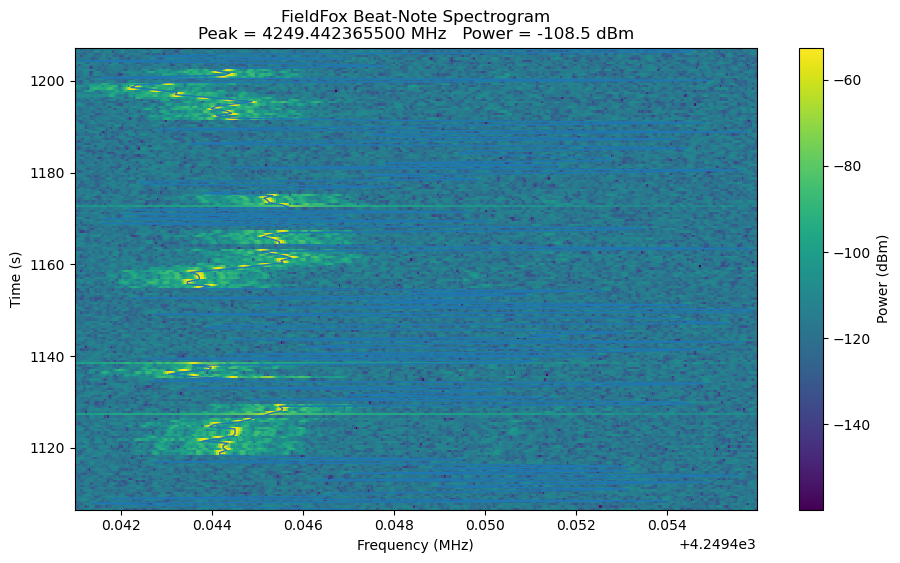

Traces collected: 3302  |  Elapsed: 1207.2 s  |  Saved: fieldfox_beatnote_20260819_143306.npz

Stopping acquisition...
Final data saved to:
fieldfox_beatnote_20260819_143306.npz
FieldFox connection closed.


In [151]:
# Full measurement history
all_spectra = []
all_times = []
all_peak_freqs = []
all_peak_powers = []

t0 = time.time()
filename = datetime.now().strftime(
    "fieldfox_beatnote_%Y%m%d_%H%M%S.npz"
)
def save_data():

    np.savez_compressed(
        filename,

        # Main measurement
        spectra=np.asarray(all_spectra),
        time_s=np.asarray(all_times),
        peak_frequency_hz=np.asarray(all_peak_freqs),
        peak_power_dbm=np.asarray(all_peak_powers),

        # Frequency axis
        frequency_hz=freq,

        # FieldFox settings at start of measurement
        start_frequency_hz=f_start,
        stop_frequency_hz=f_stop,
        sweep_points=npts,
        sweep_time_s=sweep_time
    )


try:

    while True:

        loop_start = time.time()

        # ------------------------------------------
        # READ current displayed FieldFox trace
        # ------------------------------------------
        data = ff.query("TRACE:DATA?")

        trace = np.fromstring(data, sep=",")

        if len(trace) != npts:
            print(
                f"Expected {npts} points, "
                f"received {len(trace)}"
            )
            continue

        elapsed_time = time.time() - t0

        # ------------------------------------------
        # Find beat-note peak
        # ------------------------------------------
        peak_index = np.argmax(trace)

        peak_frequency = freq[peak_index]
        peak_power = trace[peak_index]

        # ------------------------------------------
        # SAVE IN MEMORY
        # ------------------------------------------
        all_spectra.append(trace.copy())
        all_times.append(elapsed_time)
        all_peak_freqs.append(peak_frequency)
        all_peak_powers.append(peak_power)

        # ------------------------------------------
        # Periodic checkpoint to disk
        # ------------------------------------------
        if len(all_spectra) % SAVE_EVERY == 0:
            save_data()

        # ------------------------------------------
        # LIVE DISPLAY
        # Only display most recent traces
        # ------------------------------------------

        display_start = max(
            0,
            len(all_spectra) - MAX_DISPLAY_TRACES
        )

        display_spectra = np.asarray(
            all_spectra[display_start:]
        )

        display_times = np.asarray(
            all_times[display_start:]
        )

        display_peaks = np.asarray(
            all_peak_freqs[display_start:]
        )

        if len(display_times) >= 2:

            clear_output(wait=True)

            fig, ax = plt.subplots(figsize=(11, 6))

            im = ax.imshow(
                display_spectra,
                origin="lower",
                aspect="auto",
                extent=[
                    freq[0] / 1e6,
                    freq[-1] / 1e6,
                    display_times[0],
                    display_times[-1]
                ],
                interpolation="nearest"
            )

            # Peak-frequency trajectory
            ax.plot(
                display_peaks / 1e6,
                display_times,
                linewidth=1
            )

            ax.set_xlabel("Frequency (MHz)")
            ax.set_ylabel("Time (s)")

            ax.set_title(
                "FieldFox Beat-Note Spectrogram\n"
                f"Peak = {peak_frequency/1e6:.9f} MHz   "
                f"Power = {peak_power:.1f} dBm"
            )

            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label("Power (dBm)")

            plt.show()

            print(
                f"Traces collected: {len(all_spectra)}  |  "
                f"Elapsed: {elapsed_time:.1f} s  |  "
                f"Saved: {filename}"
            )

        # ------------------------------------------
        # Pace according to FieldFox sweep
        # ------------------------------------------

        loop_elapsed = time.time() - loop_start
        wait = query_interval - loop_elapsed

        if wait > 0:
            time.sleep(wait)


except KeyboardInterrupt:

    print("\nStopping acquisition...")


finally:

    # ALWAYS save everything before exiting
    if len(all_spectra) > 0:
        save_data()

        print(f"Final data saved to:")
        print(filename)

    ff.close()

    print("FieldFox connection closed.")